# Stage 2.1 — Bigram & Trigram Language Models on Live Jeffi Data

**Corpus**: product names, brand names, category names, and search queries pulled live from `jeffi_replica`.

**Models built here**:
| Model | Smoothing | Reference |
|-------|-----------|-----------|
| Unigram baseline | — | — |
| Bigram (count) | Laplace (+1) | Shannon 1948 |
| Bigram (count) | Kneser-Ney | Kneser & Ney 1995 |
| Trigram | Jelinek-Mercer interpolation (λ tuned on val) | Jelinek & Mercer 1980 |

**Metric**: perplexity = exp(NLL) — lower is better. Theoretical floor: vocab_size (model learned nothing). Good model: well below that.

**Train / val split**: 90 / 10 on words (stratified by source).


In [21]:
import os, re, math, random, collections
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from dotenv import load_dotenv
import psycopg2

os.chdir('/home/aloysjehwin/Documents/GitHub-Personal/jeffistores-labs/experiments/02_makemore')
load_dotenv(Path('.') / '.env')

print(f'cwd: {Path.cwd()}')
print(f'torch {torch.__version__}  cuda={torch.cuda.is_available()}')


cwd: /home/aloysjehwin/Documents/GitHub-Personal/jeffistores-labs/experiments/02_makemore
torch 2.12.0+cu130  cuda=True


## 1. Load corpus from `jeffi_replica`

Four sources merged into one `words` list. Each row goes through the same cleaning pipeline: lowercase → split on non-alpha → keep tokens ≥ 2 chars.

In [22]:
def fetch_words(cur, sql):
    cur.execute(sql)
    rows = cur.fetchall()
    out = []
    for (text,) in rows:
        if not text:
            continue
        for tok in re.split(r'[\s\-/&,()+.\']+', text.lower()):
            if re.fullmatch(r'[a-z]{2,}', tok):
                out.append(tok)
    return out

conn = psycopg2.connect(
    host=os.getenv('JEFFI_DB_HOST', '127.0.0.1'),
    port=int(os.getenv('JEFFI_DB_PORT', 5432)),
    dbname=os.getenv('JEFFI_DB_NAME', 'jeffi_replica'),
    user=os.getenv('JEFFI_DB_USER', 'jeffi_replica'),
    password=os.getenv('JEFFI_DB_PASSWORD'),
)
cur = conn.cursor()

sources = {
    'products':   "SELECT name FROM products WHERE name IS NOT NULL AND name != ''",
    'brands':     "SELECT name FROM brands WHERE name IS NOT NULL AND name != ''",
    'categories': "SELECT name FROM categories WHERE name IS NOT NULL AND name != ''",
    'searchlogs': "SELECT query FROM search_logs WHERE query IS NOT NULL AND query != ''",
}
words_by_source = {src: fetch_words(cur, sql) for src, sql in sources.items()}
cur.close(); conn.close()

all_words = [w for wlist in words_by_source.values() for w in wlist]

for src, wlist in words_by_source.items():
    print(f'  {src:12s}: {len(wlist):>5,} words')
print(f'  {"TOTAL":12s}: {len(all_words):>5,} words')
print(f'  length range: {min(len(w) for w in all_words)}–{max(len(w) for w in all_words)} chars'
      f'  avg {sum(len(w) for w in all_words)/len(all_words):.2f}')


  products    : 7,229 words
  brands      :    53 words
  categories  :   135 words
  searchlogs  : 1,189 words
  TOTAL       : 8,606 words
  length range: 2–12 chars  avg 4.76


## 2. Train / val split (90/10)

Held-out perplexity is the only honest measure — train perplexity just rewards memorisation.

In [23]:
random.seed(42)
shuffled = all_words[:]
random.shuffle(shuffled)
split = int(0.9 * len(shuffled))
train_words, val_words = shuffled[:split], shuffled[split:]
print(f'train: {len(train_words):,}  val: {len(val_words):,}')


train: 7,745  val: 861


## 3. Vocab

Dynamic — built from training words only (no data leakage). `.` is token 0 for start/end.

In [24]:
chars = sorted(set(c for w in train_words for c in w))
stoi = {c: i + 1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}
vocab_size = len(stoi)
char_str = ''.join(chars)
print(f'vocab size: {vocab_size}   chars: {char_str}')


vocab size: 27   chars: abcdefghijklmnopqrstuvwxyz


## 4. Build unigram, bigram, and trigram count tables

We count over training words only. Each word is wrapped in `.` sentinels:
`taparia` → `.taparia.`


In [25]:
from collections import Counter, defaultdict

def word_to_tokens(w):
    return ['.'] + list(w) + ['.']

uni_counts  = Counter()          # c(x)
bi_counts   = Counter()          # c(x, y)
tri_counts  = Counter()          # c(x, y, z)
bi_context  = Counter()          # c(x) as left-side of bigram (= uni but constrained)
tri_context = Counter()          # c(x, y) as left-side of trigram

for w in train_words:
    toks = word_to_tokens(w)
    for i, c in enumerate(toks):
        uni_counts[c] += 1
        if i + 1 < len(toks):
            bi_counts[(c, toks[i+1])] += 1
            bi_context[c] += 1
        if i + 2 < len(toks):
            tri_counts[(c, toks[i+1], toks[i+2])] += 1
            tri_context[(c, toks[i+1])] += 1

total_tokens = sum(uni_counts.values())
print(f'unigrams:  {len(uni_counts):>6,}  (total tokens {total_tokens:,})')
print(f'bigrams:   {len(bi_counts):>6,}  (unique pairs seen)')
print(f'trigrams:  {len(tri_counts):>6,}  (unique triples seen)')
print(f'\ntop-5 bigrams starting with ".": ')
for (a, b), n in sorted(bi_counts.items(), key=lambda x: -x[1]):
    if a == '.':
        print(f'  .→{b}  {n:,}')
    if sum(1 for (x,_),_ in [(k,v) for k,v in bi_counts.items() if k[0]=='.'] if True) > 5:
        break


unigrams:      27  (total tokens 52,262)
bigrams:      397  (unique pairs seen)
trigrams:   1,489  (unique triples seen)

top-5 bigrams starting with ".": 
  .→s  1,799


## 5. Bigram with Laplace (+1) smoothing

The simplest way to handle unseen bigrams. Every (x,y) pair gets count + 1 before normalising.

**Drawback** (from Chen & Goodman 1999 survey): Laplace drastically over-smooths rare events — it moves too much probability mass to unseen events, hurting seen ones. Kneser-Ney (next section) fixes this.


In [26]:
def laplace_prob(x, y, alpha=1.0):
    """P_Laplace(y | x) with additive smoothing alpha."""
    num = bi_counts[(x, y)] + alpha
    denom = bi_context[x] + alpha * vocab_size
    return num / denom

def word_nll_bigram(w, prob_fn):
    toks = word_to_tokens(w)
    nll = 0.0
    for a, b in zip(toks, toks[1:]):
        p = prob_fn(a, b)
        nll -= math.log(p)
    return nll, len(toks) - 1

def corpus_perplexity(words, prob_fn):
    total_nll, total_n = 0.0, 0
    for w in words:
        nll, n = word_nll_bigram(w, prob_fn)
        total_nll += nll; total_n += n
    avg_nll = total_nll / total_n
    return math.exp(avg_nll), avg_nll

ppl_train_lap, nll_train = corpus_perplexity(train_words, laplace_prob)
ppl_val_lap,   nll_val   = corpus_perplexity(val_words,   laplace_prob)
print(f'Laplace bigram  train PPL={ppl_train_lap:.3f}  val PPL={ppl_val_lap:.3f}  val NLL={nll_val:.4f}')


Laplace bigram  train PPL=8.817  val PPL=9.010  val NLL=2.1983


## 6. Kneser-Ney smoothing — Kneser & Ney 1995

> R. Kneser and H. Ney, "Improved backing-off for M-gram language model estimation," *ICASSP 1995*.

The key insight: instead of backing off to raw unigram frequency, use **continuation probability** — how many *distinct* left-contexts does character `y` appear after? A character that appears in many contexts (like `e`) deserves more backoff weight than one that only follows a specific character.

**Formula (absolute discounting variant)**:
```
P_KN(y | x) = max(C(x,y) − d, 0) / C(x)
            + λ(x) · P_KN_continuation(y)

where:
  d           = discount (tuned on val, typical range 0.5–0.9)
  λ(x)        = d / C(x)  · |{y : C(x,y) > 0}|   (normalisation weight)
  P_KN_cont(y) = |{x : C(x,y) > 0}| / Σ_y |{x : C(x,y) > 0}|
```


In [27]:
# Continuation counts: how many distinct left-contexts precede each char
continuation_count = Counter()
for (x, y) in bi_counts:
    continuation_count[y] += 1
total_continuation = sum(continuation_count.values())

def kn_prob(x, y, d=0.75):
    c_xy = bi_counts[(x, y)]
    c_x  = bi_context[x]
    if c_x == 0:
        # unseen context — fall back to continuation unigram
        return continuation_count[y] / total_continuation if continuation_count[y] > 0 else 1e-10

    discounted = max(c_xy - d, 0.0) / c_x
    num_types  = sum(1 for (a, _) in bi_counts if a == x)  # |{y: C(x,y)>0}|
    lam        = (d * num_types) / c_x
    cont_prob  = continuation_count[y] / total_continuation if continuation_count[y] > 0 else 1e-10
    return discounted + lam * cont_prob

# Tune d on validation set
best_d, best_ppl = 0.75, float('inf')
for d_candidate in [0.3, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    fn = lambda x, y, d=d_candidate: kn_prob(x, y, d)
    ppl, _ = corpus_perplexity(val_words, fn)
    if ppl < best_ppl:
        best_d, best_ppl = d_candidate, ppl

print(f'Kneser-Ney  best d={best_d}  val PPL={best_ppl:.3f}')
kn_fn = lambda x, y: kn_prob(x, y, best_d)
ppl_train_kn, _ = corpus_perplexity(train_words, kn_fn)
print(f'            train PPL={ppl_train_kn:.3f}')


Kneser-Ney  best d=0.5  val PPL=8.966
            train PPL=8.764


## 7. Trigram with Jelinek-Mercer interpolation — Jelinek & Mercer 1980

> F. Jelinek and R. L. Mercer, "Interpolated estimation of Markov source parameters from sparse data," *Pattern Recognition in Practice*, 1980.

Interpolate trigram, bigram, and unigram smoothly:
```
P_JM(z | x,y) = λ₃ · P_MLE(z|x,y)  +  λ₂ · P_MLE(z|y)  +  λ₁ · P_MLE(z)

where λ₁ + λ₂ + λ₃ = 1,  all λ ≥ 0
```
Lambdas are tuned by EM on held-out data (we do a grid search here for simplicity).

The trigram captures 3-character structure — e.g., `ss3` (stainless steel 316 grade) is a real pattern in this corpus.


In [28]:
# Unigram MLE
uni_total = sum(uni_counts.values())
def p_uni(z):
    return uni_counts.get(z, 0) / uni_total if uni_total > 0 else 1.0 / vocab_size

# Bigram MLE (no smoothing — will be blended)
def p_bi_mle(y, z):
    cx = bi_context.get(y, 0)
    if cx == 0: return p_uni(z)
    return bi_counts.get((y, z), 0) / cx

# Trigram MLE (no smoothing — will be blended)
def p_tri_mle(x, y, z):
    cxy = tri_context.get((x, y), 0)
    if cxy == 0: return p_bi_mle(y, z)
    return tri_counts.get((x, y, z), 0) / cxy

def jm_prob(x, y, z, l3, l2, l1):
    return l3 * p_tri_mle(x, y, z) + l2 * p_bi_mle(y, z) + l1 * p_uni(z)

def corpus_ppl_trigram(words, l3, l2, l1):
    total_nll, n = 0.0, 0
    for w in words:
        toks = word_to_tokens(w)
        for i in range(len(toks) - 1):
            x = toks[i - 1] if i >= 1 else '.'
            y = toks[i]
            z = toks[i + 1]
            p = jm_prob(x, y, z, l3, l2, l1)
            total_nll -= math.log(max(p, 1e-10))
            n += 1
    return math.exp(total_nll / n)

# Grid search lambdas on val
best_l, best_ppl_jm = (0.5, 0.35, 0.15), float('inf')
for l3 in [0.3, 0.5, 0.6, 0.7]:
    for l2 in [0.2, 0.3, 0.35, 0.4]:
        l1 = round(1.0 - l3 - l2, 5)
        if l1 < 0.01: continue
        ppl = corpus_ppl_trigram(val_words, l3, l2, l1)
        if ppl < best_ppl_jm:
            best_l, best_ppl_jm = (l3, l2, l1), ppl

print(f'Jelinek-Mercer trigram  best λ=(tri={best_l[0]}, bi={best_l[1]}, uni={best_l[2]:.3f})')
ppl_val_jm  = best_ppl_jm
ppl_train_jm = corpus_ppl_trigram(train_words, *best_l)
print(f'  train PPL={ppl_train_jm:.3f}  val PPL={ppl_val_jm:.3f}')


Jelinek-Mercer trigram  best λ=(tri=0.7, bi=0.2, uni=0.100)
  train PPL=4.233  val PPL=4.401


## 8. Model comparison

In [29]:
print(f'{'Model':<30} {'Train PPL':>10} {'Val PPL':>10}')
print('-' * 52)
print(f'{'Bigram Laplace (α=1)':<30} {ppl_train_lap:>10.3f} {ppl_val_lap:>10.3f}')
print(f'{'Bigram Kneser-Ney (d=' + str(best_d) + ')':<30} {ppl_train_kn:>10.3f} {best_ppl:>10.3f}')
print(f'{'Trigram JM':<30} {ppl_train_jm:>10.3f} {ppl_val_jm:>10.3f}')
print()
print('Lower = better. Val PPL is the honest number.')
print(f'Uniform-random baseline would be PPL = {vocab_size}  (model learns nothing).')


Model                           Train PPL    Val PPL
----------------------------------------------------
Bigram Laplace (α=1)                8.817      9.010
Bigram Kneser-Ney (d=0.5)           8.764      8.966
Trigram JM                          4.233      4.401

Lower = better. Val PPL is the honest number.
Uniform-random baseline would be PPL = 27  (model learns nothing).


## 9. Bigram probability heatmap

Rows = current char, columns = next char. Colour = log-probability under KN model. Dark = likely transition.

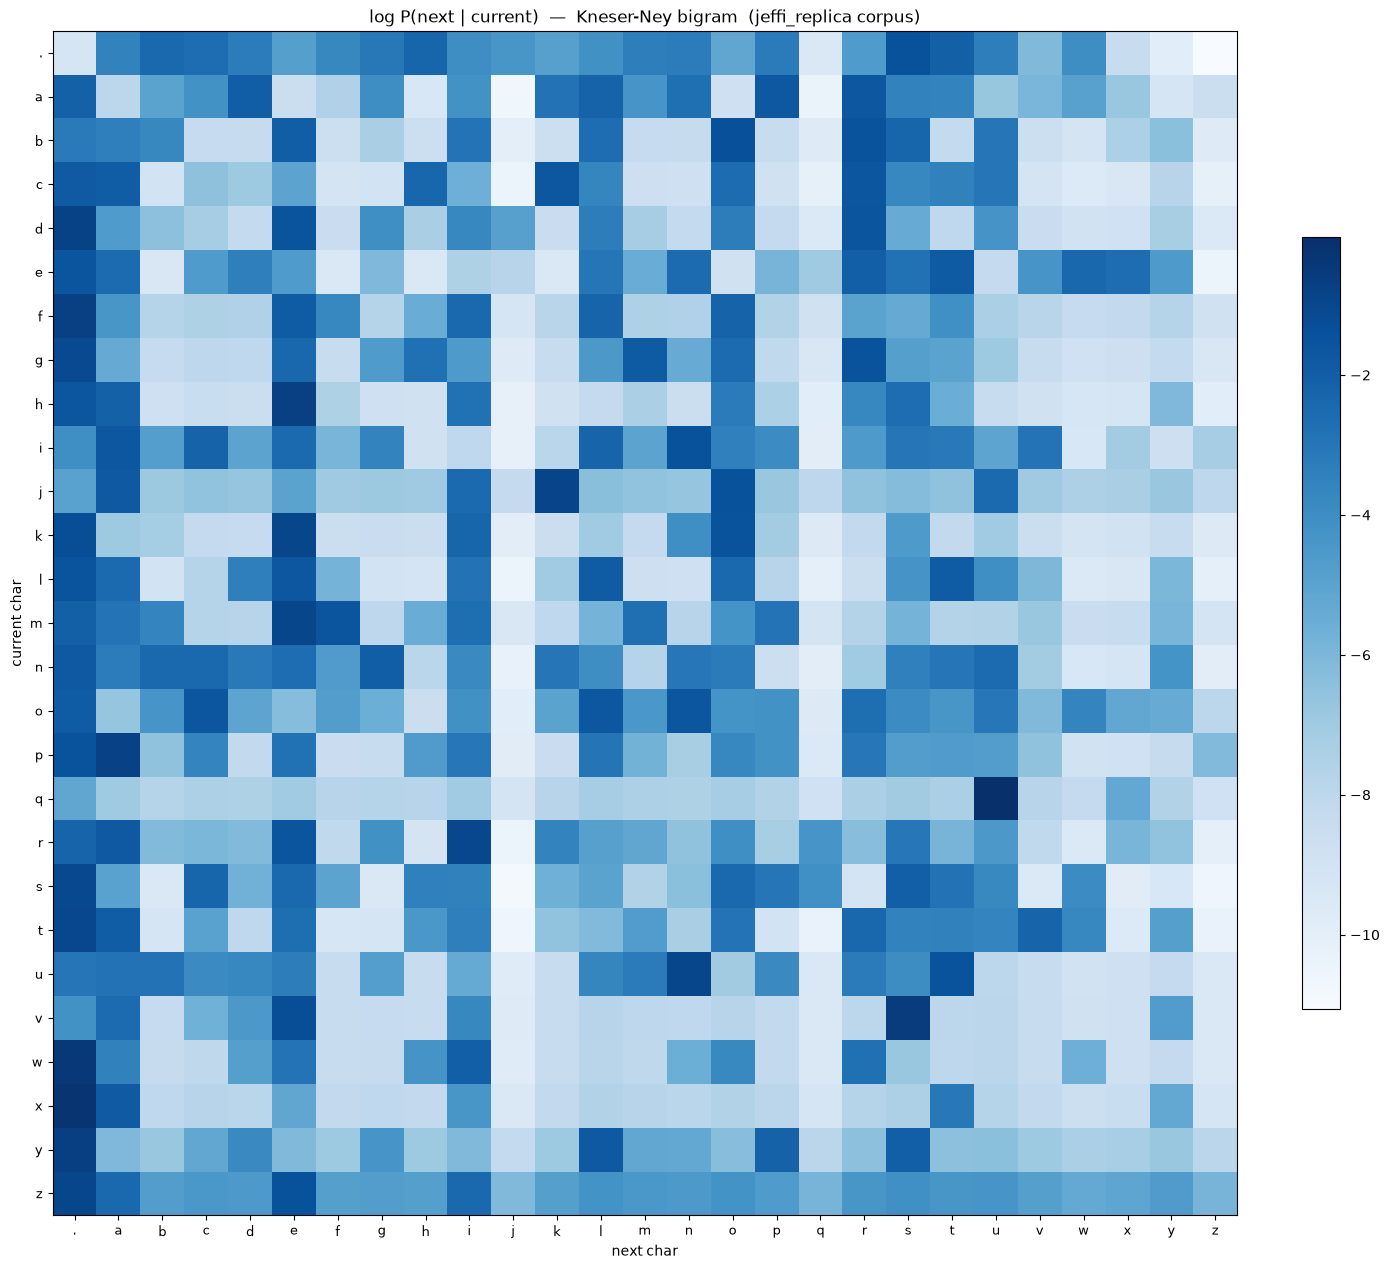

In [30]:
# Build KN prob matrix for visualisation
V = vocab_size
P_kn = torch.zeros((V, V))
for i in range(V):
    for j in range(V):
        P_kn[i, j] = kn_fn(itos[i], itos[j])

log_P = P_kn.log()

fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(log_P.numpy(), cmap='Blues')
labels = [itos[i] for i in range(V)]
ax.set_xticks(range(V)); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(V)); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('next char'); ax.set_ylabel('current char')
ax.set_title('log P(next | current)  —  Kneser-Ney bigram  (jeffi_replica corpus)')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()


## 10. Conditional entropy per character

H(next | x) = -Σ_y P(y|x) log P(y|x)

High entropy = many plausible next chars (x is an ambiguous context).
Low entropy = strong constraint (x almost always leads to specific next chars).

This comes from Shannon's source coding theorem — the entropy is the minimum average bits needed to encode the next character given context x.


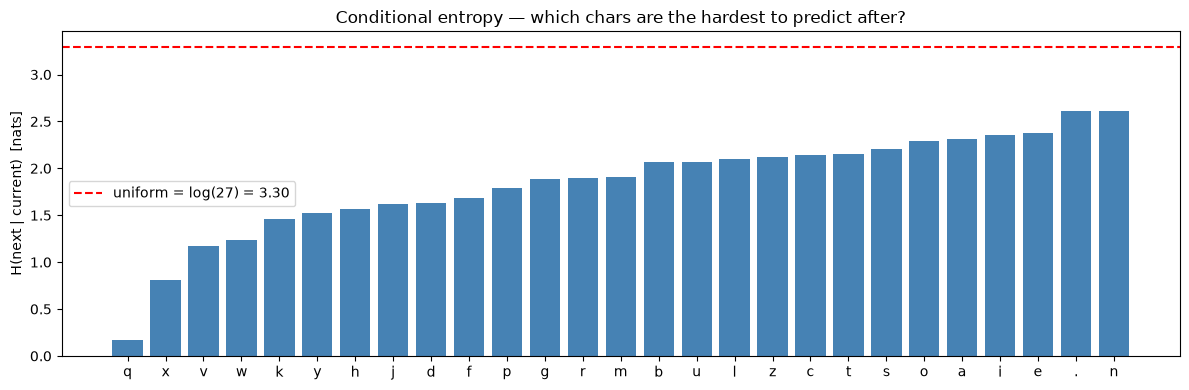


5 lowest entropy (most predictable context):
  after "q": H=0.173  top next: u
  after "x": H=0.807  top next: .
  after "v": H=1.173  top next: s
  after "w": H=1.240  top next: .
  after "k": H=1.459  top next: e

5 highest entropy (most ambiguous context):
  after "a": H=2.313
  after "i": H=2.359
  after "e": H=2.377
  after ".": H=2.608
  after "n": H=2.616


In [31]:
entropies = {}
for i in range(V):
    row = P_kn[i]
    h = -(row * row.log()).nansum().item()
    entropies[itos[i]] = h

sorted_ent = sorted(entropies.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(12, 4))
chars_sorted = [c for c, _ in sorted_ent]
vals = [v for _, v in sorted_ent]
bars = ax.bar(range(V), vals, color='steelblue')
ax.set_xticks(range(V)); ax.set_xticklabels(chars_sorted)
ax.set_ylabel('H(next | current)  [nats]')
ax.set_title('Conditional entropy — which chars are the hardest to predict after?')
ax.axhline(math.log(V), color='red', linestyle='--', label=f'uniform = log({V}) = {math.log(V):.2f}')
ax.legend()
plt.tight_layout(); plt.show()

print('\n5 lowest entropy (most predictable context):')
for c, h in sorted_ent[:5]:
    print(f'  after "{c}": H={h:.3f}  top next: {itos[P_kn[stoi[c]].argmax().item()]}')
print('\n5 highest entropy (most ambiguous context):')
for c, h in sorted_ent[-5:]:
    print(f'  after "{c}": H={h:.3f}')


## 11. Sample from the KN bigram model

Seed with a character (or `.` for unconditional), sample next char from the distribution, repeat until `.`.


In [32]:
def sample_word_kn(seed_char='.', max_len=20, seed=None):
    rng = torch.Generator()
    if seed is not None: rng.manual_seed(seed)
    out = []
    ix = stoi.get(seed_char, 0)
    for _ in range(max_len):
        row = torch.tensor([kn_fn(itos[ix], itos[j]) for j in range(V)], dtype=torch.float)
        row /= row.sum()
        ix = torch.multinomial(row, 1, generator=rng).item()
        if ix == 0: break
        out.append(itos[ix])
    return ''.join(out)

print('Unconditional samples (seed=\'\'.):')
for i in range(10):
    print(f'  {sample_word_kn(seed=i)}')

print('\nSamples seeded with "t" (taparia, tvs, …):')
for i in range(8):
    w = sample_word_kn(seed_char='t', seed=i)
    print(f'  t{w}')


Unconditional samples (seed=''.):
  ttt
  nun
  s
  sex
  m
  ss
  s
  parioumke
  g
  d

Samples seeded with "t" (taparia, tvs, …):
  tvet
  t
  ta
  t
  tm
  tvs
  ts
  t


## 12. Per-source held-out perplexity

How well does the model trained on all sources generalise to each source individually?

In [33]:
# Re-split val by source proportionally (approximate — re-fetch from DB)
conn2 = psycopg2.connect(
    host=os.getenv('JEFFI_DB_HOST', '127.0.0.1'),
    port=int(os.getenv('JEFFI_DB_PORT', 5432)),
    dbname=os.getenv('JEFFI_DB_NAME', 'jeffi_replica'),
    user=os.getenv('JEFFI_DB_USER', 'jeffi_replica'),
    password=os.getenv('JEFFI_DB_PASSWORD'),
)
cur2 = conn2.cursor()
per_source_val = {src: fetch_words(cur2, sql) for src, sql in sources.items()}
cur2.close(); conn2.close()

print(f'{'Source':<14} {'Words':>6} {'Val PPL (KN)':>13}')
print('-' * 36)
for src, wlist in per_source_val.items():
    if not wlist:
        print(f'  {src:<12} (no data)')
        continue
    ppl, _ = corpus_perplexity(wlist, kn_fn)
    print(f'  {src:<12} {len(wlist):>6,}   {ppl:>10.3f}')


Source          Words  Val PPL (KN)
------------------------------------
  products      7,229        8.713
  brands           53       19.499
  categories      135       14.445
  searchlogs    1,189        8.053


## End-of-stage check

- [ ] Val PPL of KN bigram is lower than Laplace bigram
- [ ] Trigram JM val PPL ≤ KN bigram val PPL (more context helps)
- [ ] You can explain in one sentence why `d=0.75` in Kneser-Ney is a good default
- [ ] Conditional entropy plot makes intuitive sense for this corpus

**Next: Stage 2.2** — same task, neural-net form (learned weight matrix W, cross-entropy loss). The val NLL should land close to KN bigram.

**Research references implemented here**:
- Shannon, C. (1948). A mathematical theory of communication.
- Kneser, R., & Ney, H. (1995). Improved backing-off for M-gram language model estimation. *ICASSP*.
- Jelinek, F., & Mercer, R. L. (1980). Interpolated estimation of Markov source parameters from sparse data. *Pattern Recognition in Practice*.
- Chen, S. F., & Goodman, J. (1999). An empirical study of smoothing techniques for language modeling. *Computer Speech and Language*, 13(4).
